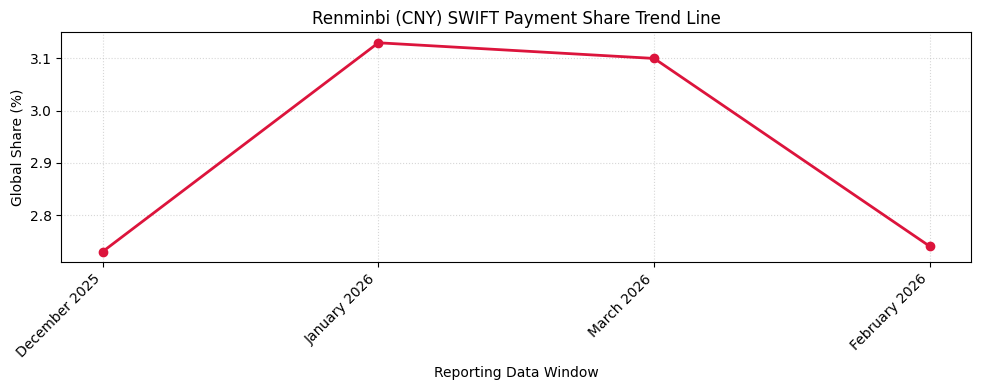


========================================= RMB METRIC SUMMARY TABLE =========================================


,Metric Description,Value (%)
0,Maximum Global Payment Share,3.130
1,Minimum Global Payment Share,2.730
2,Average Global Payment Share,2.925


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

def find_kaggle_file(filename):
    input_dir = '/kaggle/input'
    for root, dirs, files in os.walk(input_dir):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(f"Could not find {filename}")

swift_df = pd.read_csv(find_kaggle_file('swift_currency_tracker_all_reports.csv'))
swift_df.columns = swift_df.columns.str.strip()

rmb_tracking_df = swift_df[swift_df['currency_or_economy'] == 'CNY'].copy()

rmb_shares = rmb_tracking_df[rmb_tracking_df['metric'] == 'Global Payment Share'].copy()
rmb_shares['value'] = pd.to_numeric(rmb_shares['value'], errors='coerce')

summary_stats = {
    'Metric Description': [
        'Maximum Global Payment Share',
        'Minimum Global Payment Share',
        'Average Global Payment Share'
    ],
    'Value (%)': [
        rmb_shares['value'].max(),
        rmb_shares['value'].min(),
        rmb_shares['value'].mean()
    ]
}
rmb_summary_table = pd.DataFrame(summary_stats)

rmb_tracking_df.to_csv('task2_rmb_tracking.csv', index=False)
rmb_summary_table.to_csv('task2_rmb_summary_table.csv', index=False)

if not rmb_shares.empty:
    with PdfPages('task2_rmb_tracking_trend.pdf') as pdf:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(rmb_shares['data_month'], rmb_shares['value'], marker='o', color='crimson', linewidth=2)
        ax.set_title('Renminbi (CNY) SWIFT Payment Share Trend Line')
        ax.set_xlabel('Reporting Data Window')
        ax.set_ylabel('Global Share (%)')
        ax.grid(True, linestyle=':', alpha=0.5)
        fig.autofmt_xdate(rotation=45)
        plt.tight_layout()
        pdf.savefig(fig)
        plt.show()
        plt.close()

# 7. Print the table beautifully inside the notebook for the professor
print("\n========================================= RMB METRIC SUMMARY TABLE =========================================")
display(rmb_summary_table)